#####  logistic regression prediction rule 

$
\hat{y} = \sigma(wx)
$

##### Loss Function in Matrix form

$
L = -\frac{1}{m} \left[ y \log(\sigma(wx)) + (1 - y) \log(1 - \sigma(wx)) \right]
$



##### Gradient descent weight update rule.

$
w = w - \eta \frac{\Delta L}{\Delta w}
$

    Where,
    w: weights
    η: learning rate
    ΔL/Δw: gradient of the loss with respect to weights


##### After taking derivative and calculaion,

$
\frac{\Delta L}{\Delta w} = -\frac{1}{m} (y - \hat{y}) x
$


##### updated gradient descent weight update
$
w = w + \eta \cdot \frac{1}{m} (y - \hat{y}) x
$

In [29]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

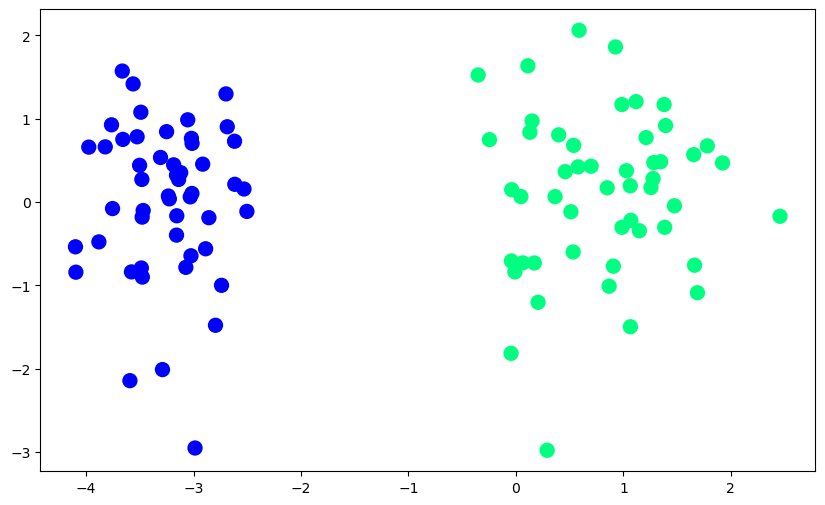

In [30]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [31]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(solver='sag',penalty=None)
lor.fit(X,y)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [32]:
print(lor.coef_)
print(lor.intercept_)

[[4.79302256 0.21215311]]
[5.76177292]


In [33]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

In [39]:
def gradientDescent(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5
    
    for i in range(4000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])
        
    return weights[1:],weights[0]
        

In [40]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [41]:
coef_,intercept_ = gradientDescent(X,y)

In [42]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

(-3.0, 2.0)

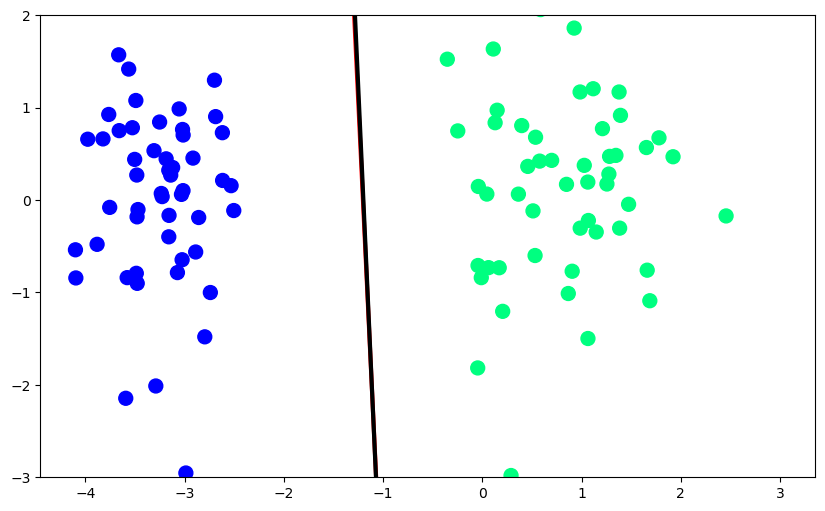

In [43]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)